## Generates plots and tables for simulation study in chapter 5

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

def align_states(Z_true, Z_model, d, T):
    Z_true = np.array(Z_true)
    Z_model = np.array(Z_model)
    
    K_true = Z_true.max() + 1
    K_model = Z_model.max() + 1
    
    # Step 1: Build confusion matrix
    C = np.zeros((K_true, K_model), dtype=int)
    for k in range(K_true):
        for j in range(K_model):
            C[k, j] = np.sum((Z_true == k) & (Z_model == j))

    # Step 2: Hungarian matching (maximize total overlap)
    row_ind, col_ind = linear_sum_assignment(-C)  # negative because scipy minimizes
    # row_ind = true state indices
    # col_ind = corresponding model state indices
    
    # Step 3: Create mapping from model state -> true state
    model_to_true = dict(zip(col_ind, row_ind))https://portal.er.kcl.ac.uk/mfa/
    
    # Any unmatched model states get a new label after K_true
    unmatched = set(range(K_model)) - set(col_ind)
    next_label = K_true
    for u in unmatched:
        model_to_true[u] = next_label
        next_label += 1

    # Step 4: Relabel model states
    Z_model_aligned = np.array([model_to_true[j] for j in Z_model])

    # Step 5: Collapse to series × state presence matrices
    A_true = np.zeros((d, K_true), dtype=int)
    B_model = np.zeros((d, next_label), dtype=int)  # include unmatched states

    for n in range(d):
        idx = slice(n*T, (n+1)*T)  # indices for this series
        # True states
        unique_true = np.unique(Z_true[idx])
        A_true[n, unique_true] = 1
        # Model states
        unique_model = np.unique(Z_model_aligned[idx])
        B_model[n, unique_model] = 1

    return A_true, B_model, Z_model_aligned, C, row_ind, col_ind

def pad_matrix(mat, max_cols):
    if mat.shape[1] < max_cols:
        pad_width = max_cols - mat.shape[1]
        mat = np.hstack([mat, np.zeros((mat.shape[0], pad_width), dtype=int)])
    return mat

def produce_matrices(Z_true, Z_models, d, T_):
    
    n = len(Z_models)
    
    A_true, B_model_sum = None, None
    
    for i in range(n):
        A_true_, B_model_, _, _, _, _ = align_states(Z_true.flatten(), np.array(Z_models[i], dtype=np.int64), d, T_)
        if i == 0:
            max_col = max(A_true_.shape[1], B_model_.shape[1])
            A_true = pad_matrix(A_true_, max_col)
            B_model_sum = pad_matrix(B_model_, max_col).astype(np.float64)
        else:
            max_col = max([A_true_.shape[1], B_model_.shape[1], A_true.shape[1], B_model_sum.shape[1]])
            A_true = pad_matrix(A_true, max_col)
            B_model_sum = pad_matrix(B_model_sum, max_col)
            B_model_ = pad_matrix(B_model_, max_col)
            
            B_model_sum += B_model_.astype(np.float64)
    
    return A_true, B_model_sum / n

def order_of_appearance(states):
    out = states.copy()
    seen = dict()
    counter = 0
    for j in range(states.shape[0]):
        for t in range(states.shape[1]):
            if states[j, t] in seen:
                out[j, t] = seen[states[j, t]]
            else:
                seen[states[j, t]] = counter
                counter += 1
                out[j, t] = seen[states[j, t]]

    return out

In [2]:
scenario = 2
dataset = 10

scenario = 1
dataset = 8

file = f'SimData/{scenario}_{dataset}.csv'
dat = np.loadtxt(file, delimiter=',')
true_states = np.loadtxt(f'SimStates/{scenario}_{dataset}.csv', delimiter=',').astype(np.int64)

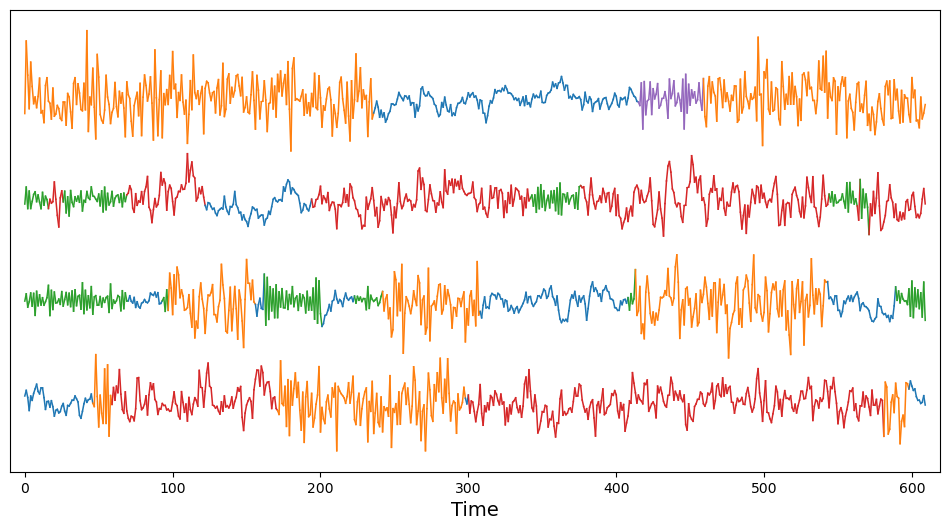

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)
x = np.arange(dat.shape[1])
shift = 13
for j in range(4):
    # ax[j].plot(dat[j, :])
    for i in range(dat.shape[1]-1):
        
        color = plt.cm.tab10(
            true_states[j, i] / 10
        )
        
        ax.plot(x[i:i+2], j*shift + dat[j, i:i+2], lw=1.1, color=color)
ax.set_yticks([])
ax.set_xlim(-10, 619)
ax.set_xlabel('Time', fontsize=14)
plt.show()

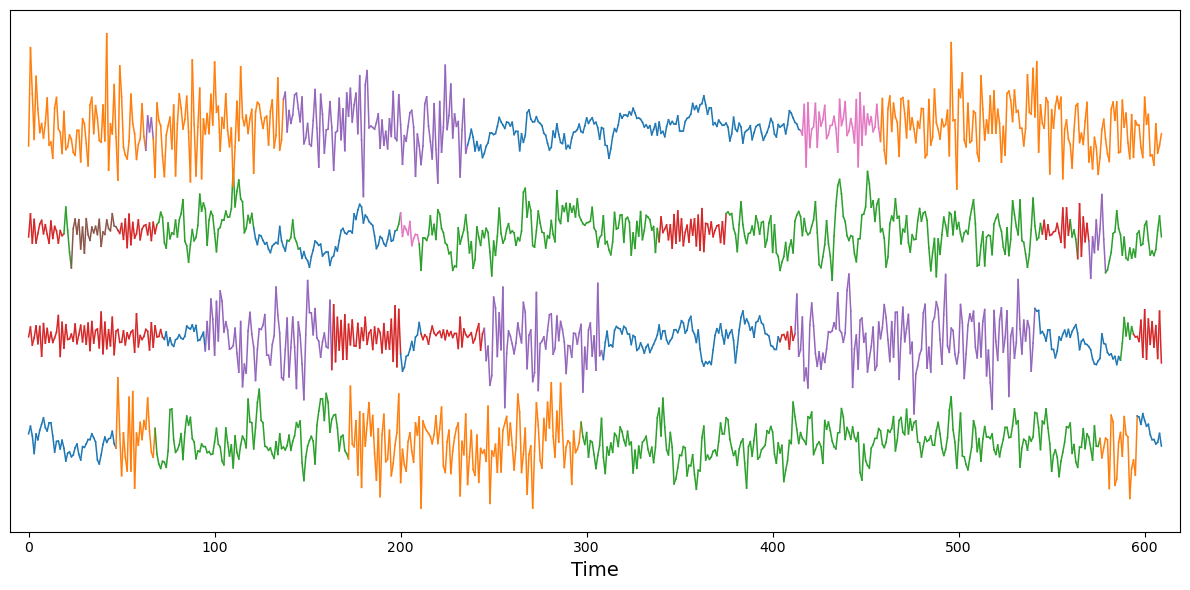

In [4]:
sampled_states = np.loadtxt(f'SimResults/sncorm_{scenario}_{dataset}_states.csv', delimiter=',').astype(np.int64)
ind = 400
sampled_states_ = sampled_states[ind, :].reshape(4, int(sampled_states[ind, :].size / 4))

fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)
x = np.arange(dat.shape[1])
shift = 10
for j in range(4):
    # ax[j].plot(dat[j, :])
    for i in range(dat.shape[1]-1):
        
        color = plt.cm.tab10(
            sampled_states_[j, i] / 10
        )
        
        ax.plot(x[i:i+2], j*shift + dat[j, i:i+2], lw=1.1, color=color)

ax.set_yticks([])
ax.set_xlim(-10, 619)
ax.set_xlabel('Time', fontsize=14)
fig.tight_layout()
fig.savefig(f'images/corm_sim_ts_{scenario}_{dataset}.pdf', bbox_inches='tight', format='pdf')
plt.show()

(1000, 2436)
(4, 610)
[[0.989 0.973 0.107 1.    0.066 0.496 0.119 0.027 0.004 0.    0.    0.
  0.   ]
 [0.996 0.965 1.    0.349 0.085 0.465 0.214 0.057 0.017 0.003 0.    0.
  0.   ]
 [0.96  0.725 1.    1.    0.253 0.436 0.353 0.176 0.051 0.013 0.004 0.
  0.   ]
 [0.995 0.998 0.063 0.048 0.994 0.26  0.083 0.022 0.004 0.003 0.001 0.001
  0.001]]


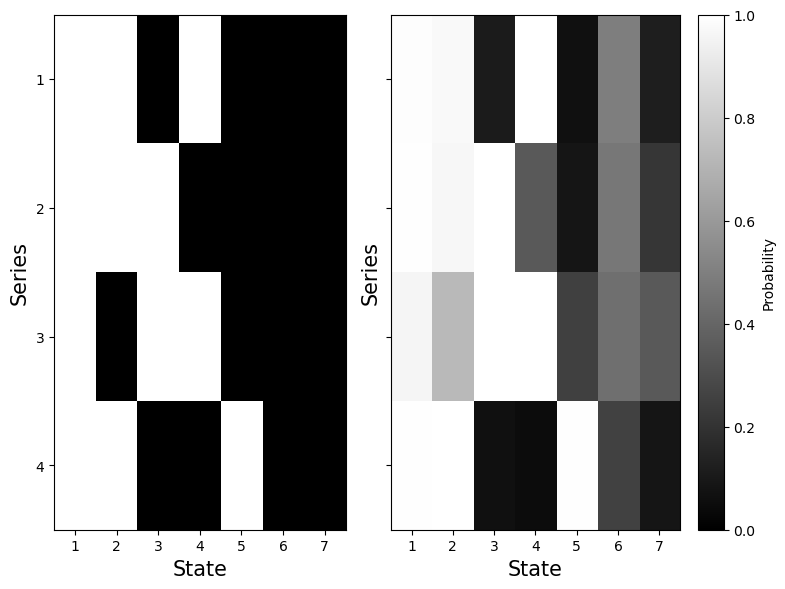

In [296]:
print(sampled_states.shape)
print(true_states.shape)
A_true, B_model = produce_matrices(true_states[:, :-1], sampled_states[:, :], 4, true_states[:, :-1].shape[1])

print(B_model)

A_true_padded = A_true
B_model_padded = B_model
max_states = A_true.shape[1]

# True states
cmap = plt.cm.gray
fig, ax = plt.subplots(1, 2, width_ratios=(0.5, 0.62), sharey=True, figsize=(8, 6))
ax[0].imshow(A_true_padded, aspect='auto', cmap=cmap, vmin=0, vmax=1)
# ax[0].set_title("True states per series")
ax[0].set_xlabel("State", fontsize=15)
ax[0].set_ylabel("Series", fontsize=15)
ax[0].set_xticks(ticks=np.arange(max_states), labels=np.arange(1, max_states+1))
ax[0].set_yticks(ticks=np.arange(4), labels=np.arange(1, 4+1))
ax[0].set_xlim(-0.5, 6.5)
im = ax[1].imshow(B_model_padded, aspect='auto', cmap=cmap, vmin=0, vmax=1)
plt.colorbar(im, ax=ax[1], label='Probability')
# ax[1].set_title("Estimated model states per series")
ax[1].set_xlabel("State", fontsize=15)
ax[1].set_ylabel("Series", fontsize=15)
ax[1].set_xticks(ticks=np.arange(max_states), labels=np.arange(1, max_states+1))
ax[1].set_yticks(ticks=np.arange(4), labels=np.arange(1, 4+1))
ax[1].set_xlim(-0.5, 6.5)
fig.tight_layout()

fig.savefig(f'images/corm_sim_grid_{scenario}_{dataset}.pdf', bbox_inches='tight', format='pdf')
plt.show()


In [16]:
models = ['sncorm', 'fox', 'ihmm', 'sticky_ihmm', 'npcp']
scenarios = [0, 1, 2, 3]
ref_model = 'sncorm'
alpha = 0.05
for model in models:
    out = f'{model} & '
    for scenario in scenarios:
        BFs = []
        for dataset in range(50):
            ref_ev = np.loadtxt(f'SimResultsClean/SimResultsClean/{ref_model}_{scenario}_{dataset}.csv', delimiter=',')[-1]
            model_ev = np.loadtxt(f'SimResultsClean/SimResultsClean/{model}_{scenario}_{dataset}.csv', delimiter=',')[-1]
            BF = model_ev - ref_ev
            BFs.append(BF)
        m = np.mean(BFs)
        l, u = np.quantile(BFs, [alpha/2, 1-alpha/2])
        out = out + f'{round(m, 2)}, ({round(l, 2)}, {round(u, 2)}) & '
    print(out)


sncorm & 0.0, (0.0, 0.0) & 0.0, (0.0, 0.0) & 0.0, (0.0, 0.0) & 0.0, (0.0, 0.0) & 
fox & -21.59, (-62.58, -2.24) & -11.36, (-28.51, 5.63) & -10.28, (-26.43, 3.69) & -8.95, (-36.98, 3.46) & 
ihmm & -18.17, (-28.45, -3.62) & -32.95, (-48.29, -13.11) & -27.47, (-35.1, -19.37) & -45.1, (-54.1, -34.8) & 
sticky_ihmm & -5.63, (-12.01, 3.88) & -14.29, (-23.05, -2.96) & -10.57, (-15.98, -3.78) & -19.76, (-26.49, -11.01) & 
npcp & -5.07, (-14.53, 3.77) & -14.4, (-21.58, -3.63) & -8.73, (-13.73, -3.39) & -19.93, (-26.95, -13.95) & 
